why we need svm?

svm is mainly used for complex data 

binary classification problems

ex: spam/ not spam
    
    cat vs dog
    
    disease/ no disease

logistic regression

it works well when data is linearly seperable but what if 

-data is complex

-classes overlap

-decision boundary is not straight

that way svm becomes powerful

y=mx+c

hyper parameters: values which are not related to data, not learned from the data

-input parameters which are directly passed to the model

to check which one is best suited for the model

-grid cell theory

-randomized cell theory

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
df.describe

<bound method NDFrame.describe of       Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-se

<Axes: >

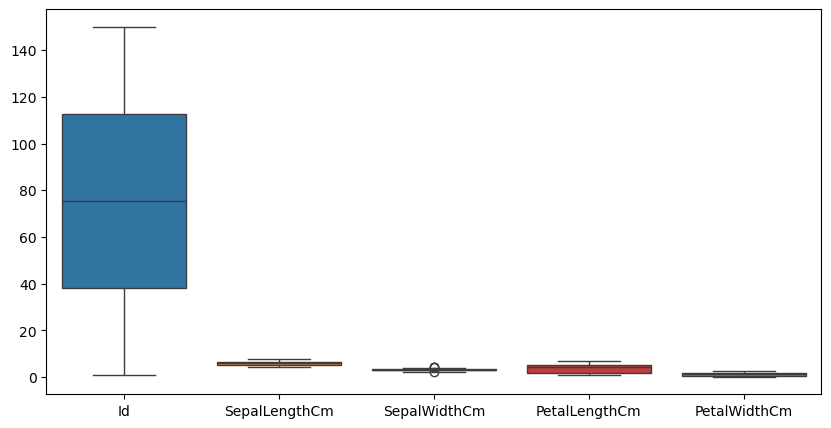

In [6]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df)

In [7]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

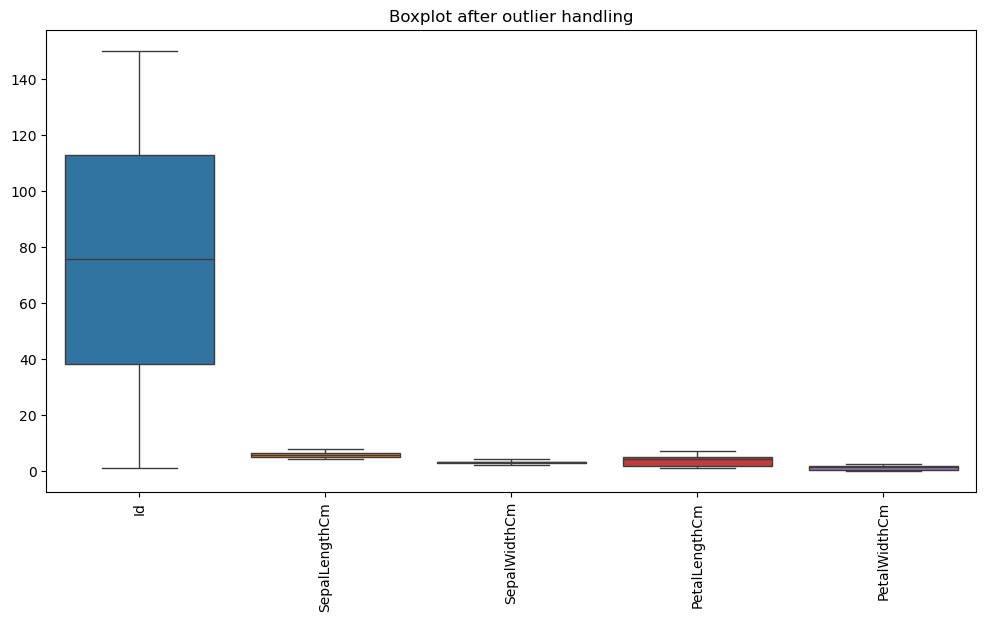

In [8]:
for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[col] = df[col].clip(lower, upper)

# verify outliers are handled
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=90)
plt.title("Boxplot after outlier handling")
plt.show()

In [9]:
X = df.drop("Species", axis=1)
y = df["Species"]
print("Independent Variables (X):")
print(X.head())
print("\nDependent Variable (y):")
print(y.head())

Independent Variables (X):
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0   1            5.1           3.5            1.4           0.2
1   2            4.9           3.0            1.4           0.2
2   3            4.7           3.2            1.3           0.2
3   4            4.6           3.1            1.5           0.2
4   5            5.0           3.6            1.4           0.2

Dependent Variable (y):
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


In [10]:
X.shape

(150, 5)

In [11]:
y.shape

(150,)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Mathematical Intuition

Eq of Hyperplane:
w.x+b=0

w=weights
x=input
b=bias/intercept

Prediction rule:
if:w.x+b>=0--> Class 1
else:w.x+b<=0--> Class 0


In [14]:
w=2
x=3
b=-4

y=w*x+b
print(y)
if y>0:
    print("class 1")
else:
    print("class 0")

2
class 1


In [15]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

svm_classifier=SVC(kernel='rbf', #Type of boundary
                   C=1.0, #Regularization parameter
                   gamma='scale' #controls the influence of data points
                   )
svm_classifier.fit(X_train,y_train)
y_pred = svm_classifier.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy:2f}")


Accuracy: 1.000000


linear= Linear data

poly= polynomial relationship

rbf= Non-Linear complex data

Sigmoid= Neural-network-like behaviour

c=1

controls overfitting vs underfitting

small c ---> wider margin ----> underfit

Large c ---> tries to classify all points ---> may overfit

gamma=scale

Controls how far the influence of one data point reaches.

High gamma --> model memorizes data

low gamma ---> generalized model

In [16]:
svm_classifier=SVC(tol=0.001, 
                   shrinking=True, 
                   coef0=0.0,
                   probability=False,
                   degree=3
                   )
svm_classifier.fit(X_train,y_train)
y_pred = svm_classifier.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy:2f}")

Accuracy: 1.000000
